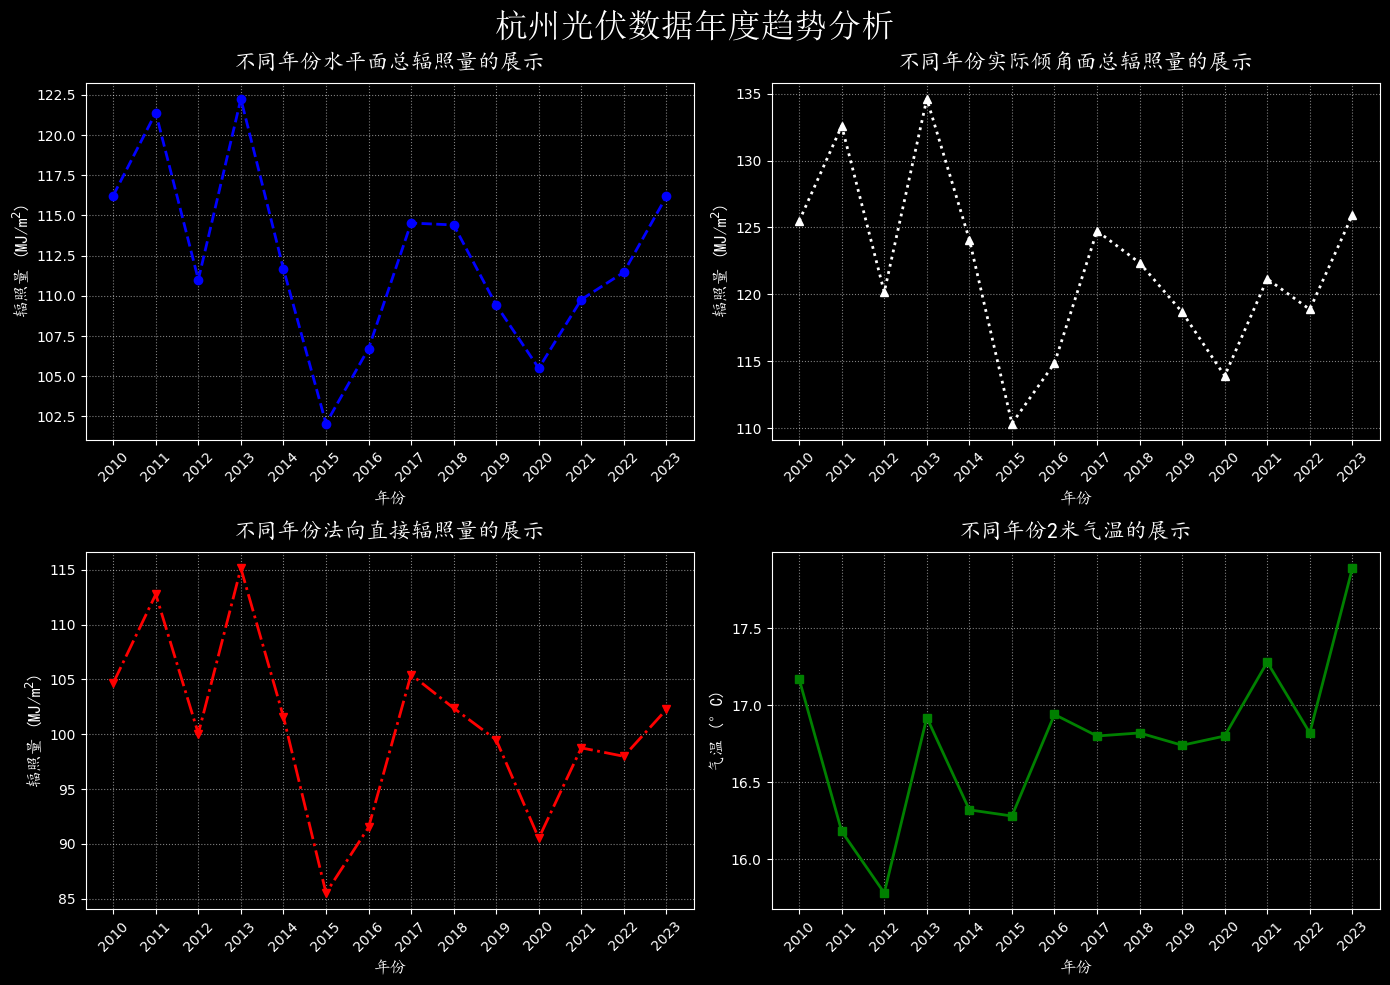

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.ufoLib import fontInfoOpenTypeOS2CodePageRangesOptions
from pandas.conftest import ascending
from pyparsing import alphas

df = pd.read_csv("C:\\Users\\someo\\Desktop\\杭州光伏数据MAX.csv",skiprows=6 ,sep = "\\s+",skipfooter=9,engine ='python')
df.columns = ['年份','月份','水平面总辐照量','最佳倾角面总辐照量','实际倾角面总辐照量','法向直接辐照量','2米气温']
df = df.groupby('年份')[['水平面总辐照量','实际倾角面总辐照量','法向直接辐照量','2米气温']].mean()
cols = ['水平面总辐照量','实际倾角面总辐照量','法向直接辐照量','2米气温']
df[cols] = df[cols].round(2)
df

# ... existing code ...
# 绘制图片
plt.figure(figsize=(14, 10))

# 1号图:破折线 + 圆点标记
plt.subplot(2,2,1)
plt.title('不同年份水平面总辐照量的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['水平面总辐照量'], linestyle='--', marker='o', color='b', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel(r'辐照量 (MJ/m$^2$)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 2号图:虚线 + 上三角标记
plt.subplot(2,2,2)
plt.title('不同年份实际倾角面总辐照量的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['实际倾角面总辐照量'], linestyle=':', marker='^', color='w', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel(r'辐照量 (MJ/m$^2$)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 3号图:点画线 + 下三角标记
plt.subplot(2,2,3)
plt.title('不同年份法向直接辐照量的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['法向直接辐照量'], linestyle='-.', marker='v', color='r', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel(r'辐照量 (MJ/m$^2$)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 4号图:方形标记
plt.subplot(2,2,4)
plt.title('不同年份2米气温的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['2米气温'], marker='s', color='g', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel('气温 (°C)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 添加总标题 - 放大并改为宋体
plt.suptitle('杭州光伏数据年度趋势分析', fontproperties='SimSun', fontsize=24, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

# ... existing code ...



Text(0.5, 1.0, '电影不同评分比例')

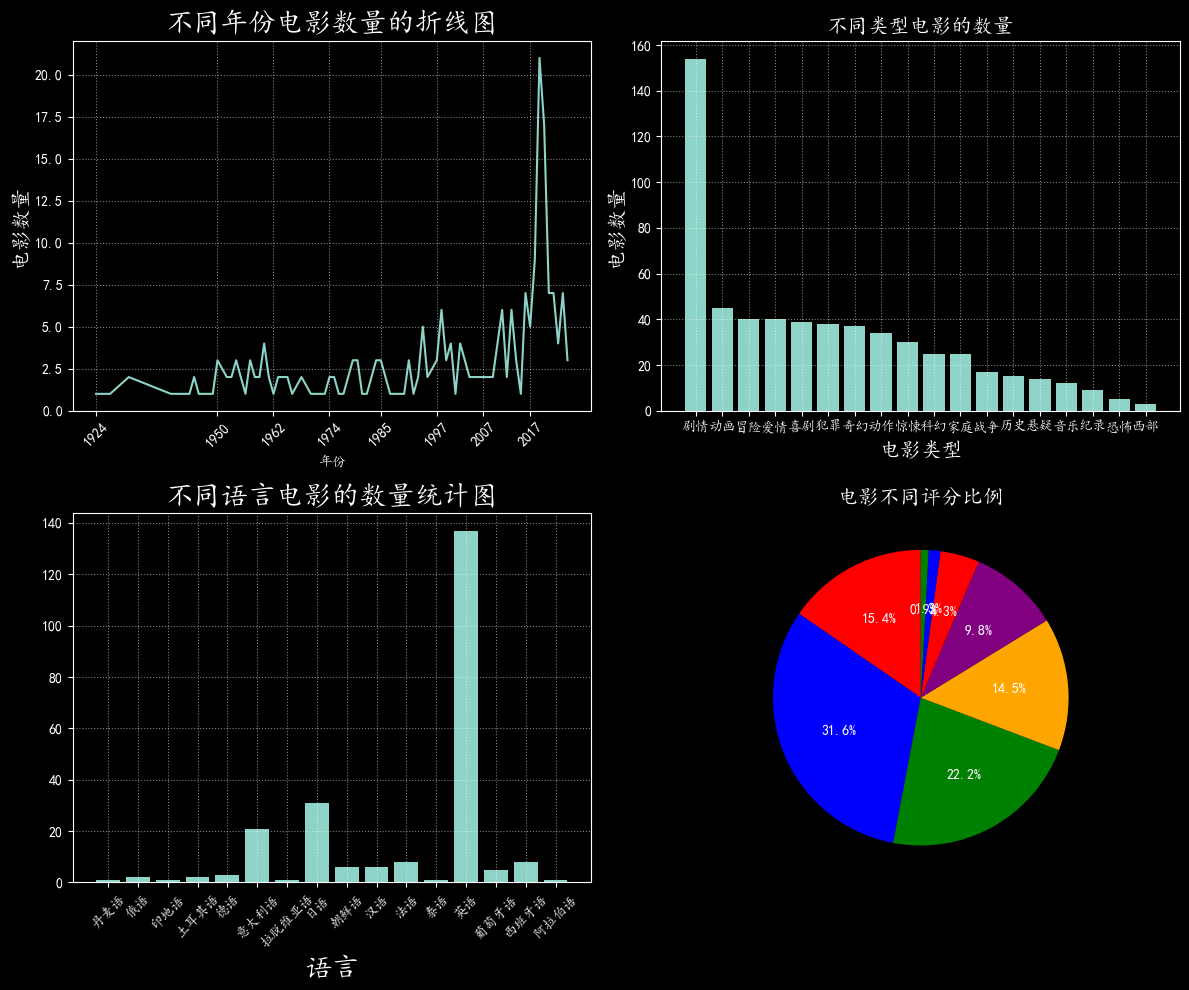

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
import numpy as np
movies_data = pd.read_csv("D:\\BaiduNetdiskDownload\\数据分析\\movies.csv",sep= ',')
#缺失值处理，直接填充上一个好像不太好，还是直接删除
#第一个图表的数据处理
movies_data = movies_data.dropna()
movies_data = movies_data.drop_duplicates(subset='电影名')
movies_data.sort_values(['年份','上映时间'],ascending=False)


# 全局设置中文字体（用你系统里有的字体）
plt.rcParams['font.family'] = 'KaiTi'
plt.rcParams['axes.unicode_minus'] = False

# 开始绘制图表
plt.figure(figsize=[12,10])
plt.subplot(2,2,1)
shu = movies_data.groupby('年份')['年份'].size()
plt.ylabel('电影数量',fontsize=15)
plt.plot(shu.index,shu)
plt.xlabel('年份',fontsize=10)
plt.xticks(shu.index[::10], rotation=45)
plt.title('不同年份电影数量的折线图',fontsize=20)
plt.grid(True,linestyle=':', alpha=0.5)

# 绘制第二份图表
#第二个图表的数据处理
language = movies_data.groupby('语言')['语言'].size()
plt.subplot(2,2,3)
plt.title('不同语言电影的数量统计图',fontsize=20)
plt.bar(language.index[::1],language)
plt.xticks(rotation=45)
plt.xlabel('语言',fontsize=20)
plt.grid(True,linestyle=':',alpha=0.5)


# 绘制第三个图表：统计不同类型电影的数量
# 1. 去除空格，按逗号拆分成列表
types_series = movies_data['类型'].str.replace(' ', '').str.split(',')

# 2. 展开成多行
types_exploded = movies_data.assign(类型=types_series).explode('类型')

# 3. 统计每个类型的数量
type_counts = types_exploded['类型'].value_counts()
plt.subplot(2,2,2)
plt.title('不同类型电影的数量',fontsize=15)
plt.bar(type_counts.index,type_counts.values)
plt.xlabel('电影类型',fontsize=15)
plt.ylabel('电影数量',fontsize=15)
plt.tight_layout()
plt.grid(True,linestyle=':',alpha=0.5)


# 第四个图表绘制，统计对比各个电影的评分比例（饼状图）
bin = movies_data.groupby('评分')['评分'].count()
# 绘制饼图
plt.subplot(2,2,4)
plt.pie(bin.values, autopct='%1.1f%%',shadow=False,startangle=90,colors=['red', 'blue', 'green', 'orange', 'purple'])
plt.title('电影不同评分比例',fontsize=15)




In [18]:
import pandas as pd
import matplotlib.pyplot as plt

def read_data():
    #加载数据
    data = pd.read_csv("D:\\浏览器下载\\Edg\\数据集\\景点数据.csv",sep=',')
    #清洗数据
    data = data.fillna('很抱歉该项数据缺失')
    # 查看是否有景点重复
    data = data.drop_duplicates(subset=['name'])
    # 删除数量这一列
    data = data.drop(columns='number')
    data = data.drop(columns='score')
    # 重新书写行索引，改成中文
    data.columns = ['景点名','等级', '地址', '宣传标语', '价格', '销售总额', '所在省份', '具体地区']

    # 按照地区，还有评分等级进行排序
    data = data.sort_values(by='所在省份', ascending=True)
    #查看数据总量
    print(f"数据总行数：{len(data)}")
    return data
read_data()








数据总行数：13617


,景点名,等级,地址,宣传标语,价格,销售总额,所在省份,具体地区
1797,上海外滩浦华大酒店,\N,上海市虹口区高阳路168号,\N,428.0,62,上海市,上海·上海·虹口区
557,上海世茂精灵之城主题乐园（深坑秘境）,\N,上海市松江区辰花路5088弄,古老神秘的峡谷丛林，翱翔天际的上古异兽,110.0,540,上海市,上海·上海·松江区
558,上海风电科普馆,\N,上海市浦东新区南汇东大路5366号,保护环境，从关注风电能源开始,10.0,81,上海市,上海·上海·浦东新区
588,BUS TOUR 上海观光游,\N,上海市黄埔区九江路588号（近湖北路）,\N,30.0,40,上海市,上海·上海·黄浦区
589,东方明珠·奇梦爱丽丝之重回仙境,\N,上海市浦东新区陆家嘴世纪大道1号东方明珠,俄罗斯技术团队根据《爱丽丝梦游仙境》开发,98.0,26,上海市,上海·上海·东方明珠
...,...,...,...,...,...,...,...,...
5641,红豆杉漂流,3A景区,黑龙江省哈尔滨市尚志市苇河镇青山种子园,原始、神秘、淳朴、险峻,0.0,0,黑龙江省,黑龙江·哈尔滨·尚志市
5642,青山国家森林公园,3A景区,黑龙江省双鸭山市岭东区?,自然风景优美，人文景观丰富多样,0.0,0,黑龙江省,黑龙江·双鸭山·岭东区
5643,月亮岛俄罗斯风情水上乐园,\N,黑龙江省鸡西市虎林市杨岗镇石头河水库风景区（密山兴凯镇东10公里）,月亮岛俄罗斯风情水上乐园空气清新，自然风光怡人，同时。月亮岛俄罗斯风情水上乐园项目总投资9....,0.0,0,黑龙江省,黑龙江·鸡西·虎林市
3404,嘉行会展蹦床馆（会展店）,\N,黑龙江省哈尔滨市南岗区长江路217号会展中心体育馆4楼,多种综合性蹦床运动项目，等你来玩,0.0,0,黑龙江省,黑龙江·哈尔滨
